In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, cKDTree
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.ndimage import maximum_filter, minimum_filter
from matplotlib.colors import LogNorm
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import Delaunay
import matplotlib.tri as mtri
from array import array
from collections import defaultdict
from matplotlib.patches import Rectangle
from pathlib import Path
from scipy.spatial import ConvexHull

In [3]:
input_folder = Path("/home/thithi/Desktop/paper/topological_defects/new/raw_data/data").expanduser()
output_folder = Path("/home/thithi/Desktop/paper/topological_defects/new/raw_data/data/hull_convex").expanduser()
print(len(list(input_folder.glob("*.csv"))))

1000


In [ ]:
#### We remove outter layers

for file in input_folder.glob("*.csv"):
    
    print(f"Processing {file.name}...")

    # read file (adjust delimiter if needed)
    df = pd.read_csv(file,sep=' ')
    positions = df[['x','y']].to_numpy()
    # read positions and velocities
    remaining = np.arange(len(positions))
        
    for _ in range(25):# remove four boundary layers
        hull = ConvexHull(positions[remaining])
        boundary = remaining[hull.vertices]
        remaining = np.setdiff1d(remaining, boundary)
        
        
    df_inside = df.iloc[remaining].copy()

    
    # create output filename
    output_file = output_folder / f"{file.stem}.csv"

    # save result
    df_inside.to_csv(output_file, index=False, sep=' ') 

In [5]:
### Movieeee
import glob
import os
import matplotlib.animation as animation

path = os.path.expanduser(
    "~/Desktop/paper/topological_defects/new/raw_data/data/hull_convex/abp2d_particles_t*.csv"
)

files = sorted(glob.glob(path))

In [6]:
files[0]

'/home/thithi/Desktop/paper/topological_defects/new/raw_data/data/hull_convex/abp2d_particles_t10000000.csv'

In [7]:
dff = pd.read_csv(files[100], sep=' ')
positions = df[['x','y']]


In [8]:
counting = []

In [9]:
for i in range(len(files)):
    df = pd.read_csv(files[i],sep=' ')
    counting.append(len(df))
    
    

In [ ]:
8064,
 7900,
 8035,
 7953,
 7959,
 7958,
 7954,
 8017,
 8024,
 8034,
 8003,
 7975,

In [10]:
counting

[8064,
 7900,
 8035,
 7953,
 7959,
 7958,
 7954,
 8017,
 8024,
 8034,
 8003,
 7975,
 7981,
 7993,
 8012,
 7925,
 8006,
 7830,
 8000,
 7989,
 7938,
 7988,
 7838,
 7877,
 7988,
 7897,
 7978,
 8003,
 7996,
 7998,
 8014,
 8027,
 7869,
 7958,
 7976,
 7961,
 7932,
 7837,
 7947,
 7959,
 7989,
 8000,
 8005,
 7935,
 8003,
 7958,
 7863,
 7995,
 7994,
 7936,
 7944,
 7975,
 7900,
 7978,
 7810,
 7950,
 7963,
 7993,
 7984,
 7973,
 7878,
 7937,
 7965,
 7951,
 7933,
 8008,
 7898,
 7887,
 7984,
 7928,
 7955,
 7986,
 7884,
 7947,
 7941,
 7925,
 7906,
 7988,
 7970,
 7969,
 7910,
 7947,
 7949,
 8005,
 7912,
 7984,
 7952,
 7972,
 7963,
 7983,
 7937,
 7951,
 7946,
 7924,
 7968,
 7989,
 7983,
 7949,
 7982,
 7889,
 8020,
 8010,
 7980,
 8014,
 7988,
 7976,
 7947,
 7984,
 8002,
 7982,
 8020,
 7954,
 8070,
 8031,
 7991,
 8039,
 7959,
 7962,
 7962,
 7955,
 8055,
 8005,
 8067,
 8070,
 8007,
 8075,
 8057,
 8042,
 8059,
 8019,
 8072,
 8104,
 8022,
 8049,
 8087,
 8058,
 8037,
 8059,
 8096,
 8090,
 8087,
 8086,
 8115,

In [15]:
min(counting)

7596

In [16]:
max(counting)

8207

In [5]:
df = pd.read_csv(files[0],sep=' ')

In [7]:
len(df)

8064

In [6]:
df

,particle_index,x,y,vx,vy,rho5,rho7,dislocation_pairs,pos(+1),neg(-1)
0,0,41.082335,15.130351,-0.801494,-0.598003,0,0,0,0,0
1,1,-24.825275,-3.126762,-0.842868,0.538120,0,0,0,0,0
2,3,18.128309,19.943668,-0.941762,-0.336280,0,0,0,0,0
3,4,10.426967,-18.838246,-0.141267,0.989971,0,0,0,0,0
4,5,11.206359,19.598663,-0.977787,0.209601,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8059,9994,-20.925993,8.776641,-0.056087,0.998426,0,0,0,0,0
8060,9995,9.658725,-3.401426,-0.757760,0.652533,0,0,0,0,0
8061,9996,-26.610483,15.523931,-0.903799,0.427958,0,0,0,0,0
8062,9998,13.768968,23.609459,0.632289,-0.774732,0,0,0,0,1


In [113]:
df = pd.read_csv(files[235],sep=' ')
disl = df['dislocation_pairs']
pos = df['pos(+1)']
cuenta=0
for i in range(len(disl)):
    if disl[i] == 1:
        cuenta=cuenta+1
        
print(cuenta)

cuenta=0
for i in range(len(disl)):
    if pos[i] == 1:
        cuenta=cuenta+1
        
print(cuenta)
print(len(disl))

226
96
8134


In [119]:
226*40

9040

In [ ]:
### Movieeee
import glob
import os
import matplotlib.animation as animation


path = os.path.expanduser(
    "~/Desktop/paper/topological_defects/new/raw_data/data/hull_convex/abp2d_particles_t*.csv"
)

files = sorted(glob.glob(path))
#second run

fig, ax = plt.subplots()
scat = ax.scatter([], [], s=0.1)

ax.set_xlim(-80, 80)   # adjust to your domain
ax.set_ylim(-100, 100)

def update(frame):
    df = pd.read_csv(
        files[frame],
        sep='\s+',
        #header=True,
        usecols=[1, 2]
    )

    scat.set_offsets(df.values)
    ax.set_title(f"t = {frame + 1}")
    return scat,

ani = animation.FuncAnimation(
    fig, update,
    frames=len(files),
    blit=True
)

output_path = os.path.expanduser(
    "/home/thithi/Desktop/paper/topological_defects/new/raw_data/data/hull_convex/movie.MOV"
)

ani.save(output_path, fps=25, dpi=200)


In [ ]:
#### Data for the Autoencoder

In [10]:
import torch

In [11]:
data_directory = Path("/home/thithi/Desktop/paper/topological_defects/new/raw_data/data/hull_convex").expanduser()
print(len(list(data_directory.glob("*.csv"))))

1000


In [60]:

def build_grid(x, y, H, W):
    """
    Define spatial grid based on particle positions
    """
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    dx = (x_max - x_min) / W # size of every pixel
    dy = (y_max - y_min) / H # size of every pixel

    # grid centers
    x_grid = x_min + (np.arange(W) + 0.5) * dx # np.arange(W) = [0,1,2,...,W-1]
    y_grid = y_min + (np.arange(H) + 0.5) * dy # y_grid = [y_min + dy/2, (y_min + 3dy/2), ...]

    return x_grid, y_grid, dx, dy


def gaussian_kernel(dx, dy, sigma): # this is the weigh of how particles will contribute to one specific pixel.
    return np.exp(-(dx**2 + dy**2) / (2 * sigma**2)) # Gaussian weights


def build_fields(x, y, vx, vy, rho5,rho7,disl, pos,neg, H=128, W=128, sigma=3):
    """
    Construct (4, H, W) tensor from particle data
    """
    angle = np.arctan2(vy, vx)
    angle = angle/np.pi #Normalizing
    x_grid, y_grid, dx, dy = build_grid(x, y, H, W)

    # Initialize fields
    density  = np.zeros((H, W))
 #   vx_field  = np.zeros((H, W))
 #   vy_field  = np.zeros((H, W))
  #  rho5_field = np.zeros((H, W))
  #  rho7_field = np.zeros((H, W))
    disl_field = np.zeros((H,W))
    angle_field = np.zeros((H,W))
    pos_field = np.zeros((H,W))
    neg_field = np.zeros((H,W))
    weight_sum = np.zeros((H, W))

    # Loop over particles. We go particle by particle and see how each particle contribute to the all the pixels
    for k in range(len(x)):
        px, py = x[k], y[k] # positions

        # Find nearby grid indices (local window for speed)
        i_min = max(0, int((py - y_grid[0]) / dy) - 3)
        i_max = min(H, int((py - y_grid[0]) / dy) + 3)
        # once the particle is in one of the pixels. We take a radius of 3 pixels each side.
        #We calculate the contribution of these particle to these neighbors pixels.
        j_min = max(0, int((px - x_grid[0]) / dx) - 3)
        j_max = min(W, int((px - x_grid[0]) / dx) + 3)

        for i in range(i_min, i_max): # we go through the neighbor pixels
            for j in range(j_min, j_max):
                dx_ij = x_grid[j] - px # distance of the particle to the pixel
                dy_ij = y_grid[i] - py

                w = gaussian_kernel(dx_ij, dy_ij, sigma) # weight

                angle_field[i, j] += angle[k] * w
                disl_field[i,j] += disl[k] * w
                pos_field[i, j] += pos[k] * w
                neg_field[i, j] += neg[k] * w
                weight_sum[i, j] += w

    # Normalize velocity fields
    mask = weight_sum > 1e-8 # mask is true when weight_sum is bigger than 10^-8
#    vx_field[mask] /= weight_sum[mask] # We normalize the weights.
#    vy_field[mask] /= weight_sum[mask] 
    disl_field[mask] /= weight_sum[mask]
    angle_field[mask] /= weight_sum[mask]
#    rho5_field[mask] /= weight_sum[mask]
#    rho7_field[mask] /= weight_sum[mask]
    pos_field[mask] /= weight_sum[mask]
    neg_field[mask] /= weight_sum[mask]

    # Stack into tensor
    I = np.stack([angle_field,disl_field, pos_field,neg_field], axis=0)# 7 channels = 4 (input) + 3 (output)
    #I = np.stack([angle_field, disl_field, pos_field,neg_field], axis=0)# 7 channels = 4 (input) + 3 (output)


    return I

CPU times: user 23 μs, sys: 0 ns, total: 23 μs
Wall time: 32.2 μs


In [61]:
%%time


i = 0
X_tensors = [] # Initialize list to store I tensors
#O_tensors = [] # Initialize list to store O tensors

for file in input_folder.glob("*.csv"):
    print(f"Processing {file.name}...")

    # Read file using whitespace as delimiter, using the recommended 'sep' argument
    df = pd.read_csv(file, sep=r'\s+')
    #particle_index=df.iloc[:,0]
    x = df.iloc[:, 1]
    y = df.iloc[:, 2]
    vx = df.iloc[:, 3]
    vy = df.iloc[:, 4]
    rho5 = df.iloc[:, 5]
    rho7 = df.iloc[:,6]
    disl = df.iloc[:,7]
    pos = df.iloc[:,8]
    neg = df.iloc[:,9]


    X = build_fields(x, y, vx, vy, rho5,rho7, disl,pos,neg, H=128, W=128, sigma=1.5)
    # Convert numpy array to torch tensor before splitting
    X_tensor = torch.from_numpy(X).float()
   # I_i, O_i = torch.split(X_tensor, [2, 2], dim=0)
    X_tensors.append(X_tensor) # Append I_i to the list
    #I_tensors.append(I_i) # Append I_i to the list
    #O_tensors.append(O_i) # Append O_i to the list
    i = i+1

import time
time.sleep(1)

Processing abp2d_particles_t9501000.csv...
Processing abp2d_particles_t9955000.csv...
Processing abp2d_particles_t9631000.csv...
Processing abp2d_particles_t9289000.csv...
Processing abp2d_particles_t9491000.csv...
Processing abp2d_particles_t9821000.csv...
Processing abp2d_particles_t9660000.csv...
Processing abp2d_particles_t9860000.csv...
Processing abp2d_particles_t9124000.csv...
Processing abp2d_particles_t9999000.csv...
Processing abp2d_particles_t9679000.csv...
Processing abp2d_particles_t9907000.csv...
Processing abp2d_particles_t9749000.csv...
Processing abp2d_particles_t9093000.csv...
Processing abp2d_particles_t9358000.csv...
Processing abp2d_particles_t9336000.csv...
Processing abp2d_particles_t9711000.csv...
Processing abp2d_particles_t9441000.csv...
Processing abp2d_particles_t9724000.csv...
Processing abp2d_particles_t9572000.csv...
Processing abp2d_particles_t9908000.csv...
Processing abp2d_particles_t9544000.csv...
Processing abp2d_particles_t9727000.csv...
Processing 

Processing abp2d_particles_t9700000.csv...
Processing abp2d_particles_t9242000.csv...
Processing abp2d_particles_t9622000.csv...
Processing abp2d_particles_t9723000.csv...
Processing abp2d_particles_t9868000.csv...
Processing abp2d_particles_t9067000.csv...
Processing abp2d_particles_t9475000.csv...
Processing abp2d_particles_t9313000.csv...
Processing abp2d_particles_t9398000.csv...
Processing abp2d_particles_t9081000.csv...
Processing abp2d_particles_t9334000.csv...
Processing abp2d_particles_t9962000.csv...
Processing abp2d_particles_t9952000.csv...
Processing abp2d_particles_t9487000.csv...
Processing abp2d_particles_t9846000.csv...
Processing abp2d_particles_t9852000.csv...
Processing abp2d_particles_t9370000.csv...
Processing abp2d_particles_t9264000.csv...
Processing abp2d_particles_t9589000.csv...
Processing abp2d_particles_t9958000.csv...
Processing abp2d_particles_t9933000.csv...
Processing abp2d_particles_t9104000.csv...
Processing abp2d_particles_t9773000.csv...
Processing 

Processing abp2d_particles_t9323000.csv...
Processing abp2d_particles_t9047000.csv...
Processing abp2d_particles_t9305000.csv...
Processing abp2d_particles_t9341000.csv...
Processing abp2d_particles_t9146000.csv...
Processing abp2d_particles_t9376000.csv...
Processing abp2d_particles_t9472000.csv...
Processing abp2d_particles_t9864000.csv...
Processing abp2d_particles_t9737000.csv...
Processing abp2d_particles_t9271000.csv...
Processing abp2d_particles_t9779000.csv...
Processing abp2d_particles_t9683000.csv...
Processing abp2d_particles_t9239000.csv...
Processing abp2d_particles_t9295000.csv...
Processing abp2d_particles_t9643000.csv...
Processing abp2d_particles_t9086000.csv...
Processing abp2d_particles_t9877000.csv...
Processing abp2d_particles_t9583000.csv...
Processing abp2d_particles_t9457000.csv...
Processing abp2d_particles_t9035000.csv...
Processing abp2d_particles_t9915000.csv...
Processing abp2d_particles_t9349000.csv...
Processing abp2d_particles_t9900000.csv...
Processing 

Processing abp2d_particles_t9162000.csv...
Processing abp2d_particles_t9558000.csv...
Processing abp2d_particles_t9149000.csv...
Processing abp2d_particles_t9729000.csv...
Processing abp2d_particles_t9392000.csv...
Processing abp2d_particles_t10000000.csv...
Processing abp2d_particles_t9682000.csv...
Processing abp2d_particles_t9582000.csv...
Processing abp2d_particles_t9800000.csv...
Processing abp2d_particles_t9980000.csv...
Processing abp2d_particles_t9964000.csv...
Processing abp2d_particles_t9632000.csv...
Processing abp2d_particles_t9516000.csv...
Processing abp2d_particles_t9011000.csv...
Processing abp2d_particles_t9619000.csv...
Processing abp2d_particles_t9311000.csv...
Processing abp2d_particles_t9117000.csv...
Processing abp2d_particles_t9527000.csv...
Processing abp2d_particles_t9362000.csv...
Processing abp2d_particles_t9213000.csv...
Processing abp2d_particles_t9394000.csv...
Processing abp2d_particles_t9993000.csv...
Processing abp2d_particles_t9090000.csv...
Processing

Processing abp2d_particles_t9221000.csv...
Processing abp2d_particles_t9741000.csv...
Processing abp2d_particles_t9649000.csv...
Processing abp2d_particles_t9012000.csv...
Processing abp2d_particles_t9910000.csv...
Processing abp2d_particles_t9921000.csv...
Processing abp2d_particles_t9103000.csv...
Processing abp2d_particles_t9871000.csv...
Processing abp2d_particles_t9044000.csv...
Processing abp2d_particles_t9247000.csv...
Processing abp2d_particles_t9020000.csv...
Processing abp2d_particles_t9465000.csv...
Processing abp2d_particles_t9367000.csv...
Processing abp2d_particles_t9596000.csv...
Processing abp2d_particles_t9809000.csv...
Processing abp2d_particles_t9409000.csv...
Processing abp2d_particles_t9428000.csv...
Processing abp2d_particles_t9808000.csv...
Processing abp2d_particles_t9387000.csv...
Processing abp2d_particles_t9210000.csv...
Processing abp2d_particles_t9532000.csv...
Processing abp2d_particles_t9592000.csv...
Processing abp2d_particles_t9265000.csv...
Processing 

Processing abp2d_particles_t9996000.csv...
Processing abp2d_particles_t9918000.csv...
Processing abp2d_particles_t9493000.csv...
Processing abp2d_particles_t9102000.csv...
Processing abp2d_particles_t9756000.csv...
Processing abp2d_particles_t9521000.csv...
Processing abp2d_particles_t9949000.csv...
Processing abp2d_particles_t9851000.csv...
Processing abp2d_particles_t9410000.csv...
Processing abp2d_particles_t9316000.csv...
Processing abp2d_particles_t9889000.csv...
Processing abp2d_particles_t9249000.csv...
Processing abp2d_particles_t9337000.csv...
Processing abp2d_particles_t9315000.csv...
Processing abp2d_particles_t9009000.csv...
Processing abp2d_particles_t9481000.csv...
Processing abp2d_particles_t9795000.csv...
Processing abp2d_particles_t9014000.csv...
Processing abp2d_particles_t9317000.csv...
Processing abp2d_particles_t9678000.csv...
Processing abp2d_particles_t9051000.csv...
Processing abp2d_particles_t9415000.csv...
Processing abp2d_particles_t9791000.csv...
Processing 

In [81]:
I_tensors = []
for i in range(len(X_tensors)):
    basura, tensors = torch.split(X_tensors[i], [1,3], dim=0)
    I_tensors.append(tensors)
print(len(I_tensors))

1000


In [82]:
torch.save(I_tensors, "tensors_autoencoder.pt")

In [14]:
### Checking the data with the tensors

In [97]:
I_tensors[0][2][23]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        1.0000, 0.4939, 0.2752, 0.1550, 0.1702, 0.2144, 0.2337, 0.2657, 0.2558,
        0.2211, 0.1410, 0.0633, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0093, 0.0214, 0.0406, 0.0559, 0.0644,
        0.0545, 0.0000, 0.0000, 0.0000, 0.0000, 0.0129, 0.0306, 0.0534, 0.0746,
        0.0806, 0.0682, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0292, 0.0598, 

In [ ]:
input_tensor = torch.load(f"{data_directory}/input_angles_tensors.pt")
output_tensor = torch.load(f"{data_directory}/output_angles_tensors.pt")

In [ ]:
#### We do the training in Collab
### We load the weights

In [16]:
input_tensor = torch.load(f"{directory}/tensors_autoencoder.pt")
output_tensor = torch.load(f"{directory}/tensors_autoencoder.pt")

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
from scipy.stats import pearsonr
from tqdm import tqdm

In [15]:
directory = Path("/home/thithi/Desktop/paper/topological_defects/new/AutoEncoder").expanduser()
print(len(list(directory.glob("*.csv"))))

0


In [17]:
input_tensor = torch.load(f"{directory}/tensors_autoencoder.pt")
output_tensor = torch.load(f"{directory}/tensors_autoencoder.pt")

In [20]:
input_tensor[0].shape

torch.Size([3, 128, 128])

In [33]:
input_tensor[0][0][0]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1576, 0.2104, 0.3397, 0.4124,
        0.5307, 0.6700, 0.7387, 0.8072, 0.7894, 0.6608, 0.4173, 0.3061, 0.1688,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0160, 0.0347, 0.0650, 0.0942, 0.1222, 0.1998, 0.2211, 0.5197,
        0.9448, 0.9217, 0.9005, 0.8720, 0.8618, 0.7322, 0.6571, 0.3572, 0.2626,
        0.1978, 0.1800, 0.3262, 0.6004, 0.6178, 0.3536, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

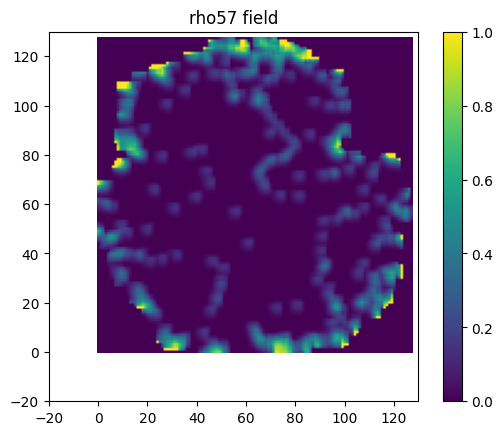

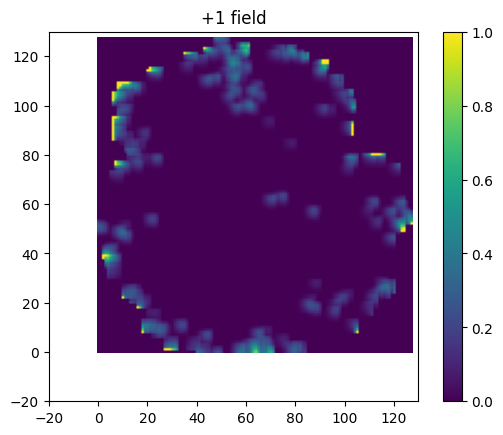

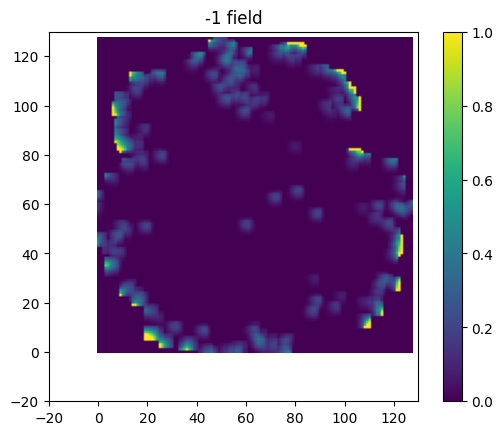

In [34]:
import matplotlib.pyplot as plt

plt.imshow(input_tensor[0][0])# I[0] = t9501000
plt.colorbar()
plt.title("rho57 field")
plt.xlim(-20,130)
plt.ylim(-20,130)
plt.show()

plt.imshow(input_tensor[0][1])
plt.colorbar()
plt.title("+1 field")
plt.xlim(-20,130)
plt.ylim(-20,130)
plt.show()


plt.imshow(input_tensor[0][2])
plt.colorbar()
plt.title("-1 field")
plt.xlim(-20,130)
plt.ylim(-20,130)
plt.show()




In [163]:
# Calculate the split index for 80% training and 20% validation
# Convert input_tensor and output_tensor from lists of tensors to single stacked tensors
stacked_input_tensor = torch.stack(input_tensor, dim=0)
stacked_output_tensor = torch.stack(output_tensor, dim=0)  # Shape: torch.Size([3, 128, 128])
#stacked_output_tensor = stacked_output_tensor[:,:2, :, :]  # Shape: torch.Size([2, 128, 128])

print(stacked_output_tensor.shape)
total_samples = len(stacked_input_tensor) # Use the length of the stacked tensor
train_size = int(0.8 * total_samples)

# Split the stacked tensors
# torch.randperm returns a random permutation of indices, which
# ensures the split is randomised (not just the last N samples).
perm = torch.randperm(total_samples)

# Now, index the stacked tensors using the permutation directly
Input = stacked_input_tensor[perm[:train_size]]
Output = stacked_output_tensor[perm[:train_size]]
Input_val = stacked_input_tensor[perm[train_size:]]
Output_val = stacked_output_tensor[perm[train_size:]]


# Print the shape of the combined tensors to verify
print(f"Input (training) shape: {Input.shape}")
print(f"Output (training) shape: {Output.shape}")
print(f"Input (validation) shape: {Input_val.shape}")
print(f"Output (validation) shape: {Output_val.shape}")

torch.Size([1000, 3, 128, 128])
Input (training) shape: torch.Size([800, 3, 128, 128])
Output (training) shape: torch.Size([800, 3, 128, 128])
Input (validation) shape: torch.Size([200, 3, 128, 128])
Output (validation) shape: torch.Size([200, 3, 128, 128])


In [164]:
# ─────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────

class TensorDataset(Dataset):
    """
    Wraps pre-loaded input and target tensors into a PyTorch Dataset.

    inputs  : FloatTensor of shape (N, 3, 128, 128)
    targets : FloatTensor of shape (N, 2, 128, 128)
    """

    def __init__(self, inputs: torch.Tensor, targets: torch.Tensor):
        # Basic sanity check: number of samples must match.
        assert inputs.shape[0] == targets.shape[0], \
            "inputs and targets must have the same number of samples"
        self.inputs  = inputs
        self.targets = targets

    def __len__(self) -> int:
        # DataLoader calls this to know the total number of samples.
        return self.inputs.shape[0]

    def __getitem__(self, idx: int):
        # Returns a single (input, target) pair by index.
        # DataLoader will stack these into batches automatically.
        return self.inputs[idx], self.targets[idx]


In [165]:
# ── DataLoaders ──────────────────────────────────────────
# DataLoader handles batching, shuffling, and (optionally)
# multi-process data loading (num_workers > 0).
batch_size = 8
train_loader = DataLoader(
    TensorDataset(Input, Output),
    batch_size=batch_size,
    shuffle=True,    # shuffle every epoch to reduce overfitting
)
val_loader = DataLoader(
    TensorDataset(Input_val, Output_val),
    batch_size=batch_size,
    shuffle=False,   # no need to shuffle validation data
)

dataloader= DataLoader(
    TensorDataset(stacked_input_tensor, stacked_output_tensor),
    batch_size=batch_size,
    shuffle=True,    # shuffle every epoch to reduce overfitting
)

In [166]:
class DoubleConv(nn.Module):
    """
    Two consecutive Conv → BatchNorm → ReLU sequences.
    This is the basic building block used in every encoder
    and decoder stage of the U-Net.

    in_channels  : number of feature maps coming in
    out_channels : number of feature maps going out
    """


    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.block = nn.Sequential(
            # First convolution: slides a 3×3 kernel over the input.
            # padding=1 keeps the spatial size (H, W) unchanged.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),

            # BatchNorm normalises each channel over the batch so that activations stay in a healthy numerical range.
            #This stabilises and accelerates training. bias=False above is intentional: BatchNorm has its own learnable bias (beta).
            nn.BatchNorm2d(out_channels),

            # ReLU introduces non-linearity, letting the network learn complex mappings. inplace=True modifies the tensor in memory,
            #saving a small amount of RAM.
            nn.ReLU(inplace=True),

            # Second convolution, same idea as above.
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Simply pass x through all layers defined in self.block.
        return self.block(x)


In [167]:
# ─────────────────────────────────────────────────────────────
# Autoencoder
# ─────────────────────────────────────────────────────────────

class Autoencoder(nn.Module):
    """
    Full U-Net.

    Encoder path  : 4 stages, each doubles the channel count and
                    halves spatial resolution via MaxPool.
    Bottleneck    : deepest representation (no pooling).
    Decoder path  : 4 stages, each halves the channel count and
                    doubles spatial resolution via ConvTranspose2d.
    Skip connections: feature maps from each encoder stage are
                    concatenated to the corresponding decoder stage,
                    giving the decoder access to fine spatial detail
                    that would otherwise be lost during downsampling.

    in_channels   : channels of the input tensor  (3 for RGB)
    out_channels  : channels of the output tensor (2 for your task)
    features      : base channel width; doubles at each encoder stage
    """

    def __init__(self, in_channels: int = 3, out_channels: int = 3,
                 features: int = 64):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────
        # Each DoubleConv extracts richer features at a coarser scale.
        # Stored in a ModuleList so PyTorch registers them as parameters.

        self.enc1 = DoubleConv(in_channels, features)         # 4  → 64  ch
        self.enc2 = DoubleConv(features,     features * 2)    # 64 → 128 ch
        self.enc3 = DoubleConv(features * 2, features * 4)    # 128→ 256 ch
        self.enc4 = DoubleConv(features * 4, features * 8)    # 256→ 512 ch

        # MaxPool halves each spatial dimension (128→64→32→16→8).
        # kernel_size=2, stride=2 means every non-overlapping 2×2
        # region collapses to one value (the maximum).
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Bottleneck ────────────────────────────────────────
        # Deepest layer: 8×8 spatial size, 1024 channels.
        # No pooling here — we immediately start going back up.
        self.bottleneck = DoubleConv(features * 8, features * 16)  # 512→1024 ch

        # ── Decoder ──────────────────────────────────────────
        # ConvTranspose2d is the "learnable upsampling" step.
        # kernel_size=2, stride=2 doubles H and W (inverse of MaxPool).
        # After upsampling, the skip connection is concatenated, so the
        # next DoubleConv sees (upsampled_channels + skip_channels).

        # Stage 4: upsample 1024→512, then concat skip4 (512) → input 1024
        #ConvTranspose2d is like the inverse of MaxPool.
        self.up4   = nn.ConvTranspose2d(features * 16, features * 8,
                                        kernel_size=2, stride=2)
        self.dec4  = DoubleConv(features * 16, features * 8)   # 1024→512 ch

        # Stage 3: upsample 512→256, concat skip3 (256) → input 512
        self.up3   = nn.ConvTranspose2d(features * 8, features * 4,
                                        kernel_size=2, stride=2)
        self.dec3  = DoubleConv(features * 8, features * 4)    # 512→256 ch

        # Stage 2: upsample 256→128, concat skip2 (128) → input 256
        self.up2   = nn.ConvTranspose2d(features * 4, features * 2,
                                        kernel_size=2, stride=2)
        self.dec2  = DoubleConv(features * 4, features * 2)    # 256→128 ch

        # Stage 1: upsample 128→64, concat skip1 (64) → input 128
        self.up1   = nn.ConvTranspose2d(features * 2, features,
                                        kernel_size=2, stride=2)
        self.dec1  = DoubleConv(features * 2, features)        # 128→64 ch

        # ── Output head ──────────────────────────────────────
        # A 1×1(kernel) convolution maps 64 channels → out_channels (2).
        # No activation here — apply softmax/sigmoid outside if needed.
        self.output_conv = nn.Conv2d(features, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Encoder forward ──────────────────────────────────
        # Each skip_N tensor is saved to be concatenated later.

        skip1 = self.enc1(x)            # (B,  64, 128, 128)
        skip2 = self.enc2(self.pool(skip1))   # (B, 128,  64,  64)
        skip3 = self.enc3(self.pool(skip2))   # (B, 256,  32,  32)
        skip4 = self.enc4(self.pool(skip3))   # (B, 512,  16,  16)

        # ── Bottleneck ────────────────────────────────────────
        x = self.bottleneck(self.pool(skip4))  # (B, 1024, 8, 8)
        
        # SAVE LATENT SPACE
        self.bottleneck_features = x

        # ── Decoder forward ──────────────────────────────────
        # torch.cat concatenates along the channel dimension (dim=1).
        # This is the "U" in U-Net: the skip gives the decoder exact
        # spatial information from the corresponding encoder stage.

        x = self.up4(x)                        # (B, 512, 16, 16)
        x = torch.cat([x, skip4], dim=1)       # (B, 1024, 16, 16) #I dont understand the cocatenation
        x = self.dec4(x)                       # (B, 512, 16, 16)

        x = self.up3(x)                        # (B, 256, 32, 32)
        x = torch.cat([x, skip3], dim=1)       # (B, 512, 32, 32)
        x = self.dec3(x)                       # (B, 256, 32, 32)

        x = self.up2(x)                        # (B, 128, 64, 64)
        x = torch.cat([x, skip2], dim=1)       # (B, 256, 64, 64)
        x = self.dec2(x)                       # (B, 128, 64, 64)

        x = self.up1(x)                        # (B, 64, 128, 128)
        x = torch.cat([x, skip1], dim=1)       # (B, 128, 128, 128)
        x = self.dec1(x)                       # (B, 64, 128, 128)

        # ── Output ───────────────────────────────────────────
        return self.output_conv(x)             # (B, 2, 128, 128)

In [168]:
#We read the weight trainings.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = Autoencoder()
model.load_state_dict(torch.load("autoencoder_weights.pth",map_location=torch.device('cpu')))
model.to(device)
model.eval()

Autoencoder(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (bl

In [169]:
# Connection to the latent space 
latent_features = {}

def latent_hook(module, input, output):
    latent_features["z"] = output.detach()

# Register hook
hook_handle = model.bottleneck.register_forward_hook(latent_hook)

In [170]:
# Register hook
hook_handle = model.bottleneck.register_forward_hook(latent_hook)
# Register hook
hook_handle = model.bottleneck.register_forward_hook(latent_hook)
# This function gets the latent features.
def get_latent_representation(x):

    with torch.no_grad():
        _ = model(x)

    z = latent_features["z"]

    return z

In [171]:
# This function remove the channel 3.
def mask_channel34(x):

    x_masked = x.clone()

    # Zero-out third channel
    noise0 = torch.randn_like(x[:,2,:,:]) * 0.1
    noise1 = torch.randn_like(x[:,3,:,:]) * 0.1
    x_masked[:,2,:,:] = noise0
    x_masked[:,3,:,:] = noise1
   # x_masked[:, 2, :, :] = 0

    return x_masked

In [172]:
# This function remove the channel 3.
def mask_channel12(x):

    x_masked = x.clone()

    # Zero-out third channel
    noise0 = torch.randn_like(x[:,0,:,:]) * 0.1
    noise1 = torch.randn_like(x[:,1,:,:]) * 0.1
    x_masked[:,0,:,:] = noise0
 #   x_masked[:,1,:,:] = noise1
   # x_masked[:, 2, :, :] = 0

    return x_masked

In [173]:
# We measure the correlation with pearson coeffients.

def compute_pearson(z1, z2):

    z1_flat = z1.flatten().cpu().numpy()
    z2_flat = z2.flatten().cpu().numpy()

    corr, _ = pearsonr(z1_flat, z2_flat)

    return corr

In [179]:
def latent_correlation_analysis(x):

    x = x.to(device)

    # ORIGINAL INPUT
    z_original = get_latent_representation(x)
   # print(z_original)
    #print(z_original.shape)
    # MASKED INPUT
    x_masked = mask_channel12(x)

    z_masked = get_latent_representation(x_masked)

    # METRICS
    pearson_corr = compute_pearson(
        z_original,
        z_masked
    )

#     cosine_sim = compute_cosine_similarity(
#         z_original,
#         z_masked
#     )

    return {
        "pearson_corr": pearson_corr
        #,  "cosine_similarity": cosine_sim
    }

In [180]:
# Pearson correlation when we mask the velocity fields = 0.
# it means  (vx,vy,+1,-1) -> (rho5,rho7) ----> (0,0,+1,-1) -> (rho5,rho7)

# Mean Pearson Correlation = 0.13549925
# This measures the correlation between (+1,-1) and (rho5,rho7)
pearson_scores = []
cosine_scores = []

for batch in tqdm(dataloader):

    x = batch[0].to(device)

    results = latent_correlation_analysis(x)
    
    pearson_scores.append(
        results["pearson_corr"]
    )

 #   cosine_scores.append(
 #       results["cosine_similarity"]
 #   )

print("\nRESULTS")
print("========")

print("Pearson Correlation:")
print(pearson_scores)

print("Mean Pearson Correlation:")
print(np.mean(pearson_scores))

#print("\nMean Cosine Similarity:")
#print(np.mean(cosine_scores))

100%|█████████████████████████████████████████| 125/125 [05:34<00:00,  2.68s/it]


RESULTS
Pearson Correlation:
[np.float32(0.8566459), np.float32(0.8491699), np.float32(0.8433885), np.float32(0.8744543), np.float32(0.8546443), np.float32(0.8513738), np.float32(0.82686454), np.float32(0.85594225), np.float32(0.88079756), np.float32(0.86129713), np.float32(0.8661779), np.float32(0.8543026), np.float32(0.84630823), np.float32(0.86175746), np.float32(0.8561896), np.float32(0.8425399), np.float32(0.86432326), np.float32(0.8672749), np.float32(0.8544452), np.float32(0.887334), np.float32(0.8583579), np.float32(0.86113286), np.float32(0.8643515), np.float32(0.8493221), np.float32(0.87166196), np.float32(0.89057946), np.float32(0.8700849), np.float32(0.87599456), np.float32(0.85876673), np.float32(0.8546603), np.float32(0.8516169), np.float32(0.87405694), np.float32(0.8710968), np.float32(0.8986021), np.float32(0.88484234), np.float32(0.8890266), np.float32(0.85988134), np.float32(0.84466636), np.float32(0.83350813), np.float32(0.8782057), np.float32(0.8662391), np.float32

In [ ]:
##PCA

In [181]:
def get_latent(model, X, device):

    model.eval()

    with torch.no_grad():

        X = X.to(device)

        _ = model(X)

        latent = model.bottleneck_features # U-net has saved the bottleneck_features

    return latent.cpu().numpy()

In [182]:
latent_full = []

for X_batch, _ in dataloader:

    z = get_latent(model,X_batch,device)

    z = z.reshape(z.shape[0], -1) # Flatten:      (B,C,H,W) -> (B,C*H*W)

    latent_full.append(z)

latent_full = np.concatenate(latent_full,axis=0)

In [184]:
print(latent_full.shape)

(1000, 65536)


In [185]:
latent_masked = []

for X_batch, _ in dataloader:

    X_masked = X_batch.clone()

    X_masked[:, 0, :, :] = 0 # rho57 is masked
   # X_masked[:, 1, :, :] = 0 # vy is masked


    z = get_latent(
        model,
        X_masked,
        device
    )

    z = z.reshape(z.shape[0], -1)

    latent_masked.append(z)

latent_masked = np.concatenate(latent_masked,axis=0)
print(latent_masked)

[[0.46466067 1.0136094  1.9961247  ... 0.         0.         0.        ]
 [0.6564599  0.4746515  0.89566725 ... 0.         0.         0.        ]
 [0.20880644 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.01953015 0.         0.         ... 0.         0.         0.        ]
 [0.54052675 0.06093269 0.         ... 0.         0.         0.        ]
 [0.52858394 0.5737387  1.040761   ... 0.         0.         0.        ]]


In [186]:
print(latent_masked.shape)

(1000, 65536)


In [187]:
latent_all = np.vstack([
    latent_full,
    latent_masked
])

labels = np.concatenate([
    np.zeros(len(latent_full)),
    np.ones(len(latent_masked))
])

In [188]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_all)

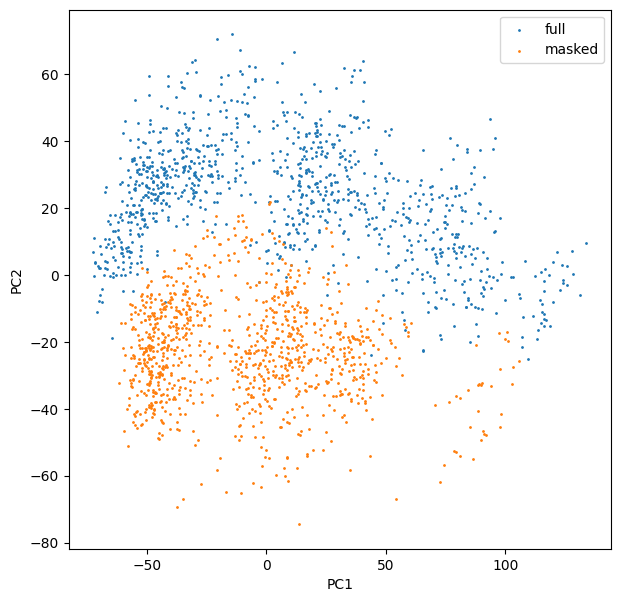

In [190]:
plt.figure(figsize=(7,7))

plt.scatter(
    latent_2d[labels==0,0],
    latent_2d[labels==0,1],
    label="full",s=1
)

plt.scatter(
    latent_2d[labels==1,0],
    latent_2d[labels==1,1],
    label="masked",s=1
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()

plt.show()

In [ ]:
### It did not change that much because the rho+- did not learn from the dislocation pairs

In [ ]:
## Now lets see the PCA when the trainning has been weighted

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
from scipy.stats import pearsonr
from tqdm import tqdm

In [41]:
directory = Path("/home/thithi/Desktop/paper/topological_defects/new/AutoEncoder").expanduser()
#print(len(list(directory.glob("*.csv"))))

input_tensor = torch.load(f"{directory}/tensors_autoencoder.pt")
output_tensor = torch.load(f"{directory}/tensors_autoencoder.pt")

In [43]:
len(input_tensor)

1000

In [44]:
# Calculate the split index for 80% training and 20% validation
# Convert input_tensor and output_tensor from lists of tensors to single stacked tensors
stacked_input_tensor = torch.stack(input_tensor, dim=0)
stacked_output_tensor = torch.stack(output_tensor, dim=0)  # Shape: torch.Size([3, 128, 128])
#stacked_output_tensor = stacked_output_tensor[:,:2, :, :]  # Shape: torch.Size([2, 128, 128])

print(stacked_output_tensor.shape)
total_samples = len(stacked_input_tensor) # Use the length of the stacked tensor
train_size = int(0.8 * total_samples)

# Split the stacked tensors
# torch.randperm returns a random permutation of indices, which
# ensures the split is randomised (not just the last N samples).
perm = torch.randperm(total_samples)

# Now, index the stacked tensors using the permutation directly
Input = stacked_input_tensor[perm[:train_size]]
Output = stacked_output_tensor[perm[:train_size]]
Input_val = stacked_input_tensor[perm[train_size:]]
Output_val = stacked_output_tensor[perm[train_size:]]


# Print the shape of the combined tensors to verify
print(f"Input (training) shape: {Input.shape}")
print(f"Output (training) shape: {Output.shape}")
print(f"Input (validation) shape: {Input_val.shape}")
print(f"Output (validation) shape: {Output_val.shape}")

torch.Size([1000, 3, 128, 128])
Input (training) shape: torch.Size([800, 3, 128, 128])
Output (training) shape: torch.Size([800, 3, 128, 128])
Input (validation) shape: torch.Size([200, 3, 128, 128])
Output (validation) shape: torch.Size([200, 3, 128, 128])


In [45]:
# ─────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────

class TensorDataset(Dataset):
    """
    Wraps pre-loaded input and target tensors into a PyTorch Dataset.

    inputs  : FloatTensor of shape (N, 3, 128, 128)
    targets : FloatTensor of shape (N, 2, 128, 128)
    """

    def __init__(self, inputs: torch.Tensor, targets: torch.Tensor):
        # Basic sanity check: number of samples must match.
        assert inputs.shape[0] == targets.shape[0], \
            "inputs and targets must have the same number of samples"
        self.inputs  = inputs
        self.targets = targets

    def __len__(self) -> int:
        # DataLoader calls this to know the total number of samples.
        return self.inputs.shape[0]

    def __getitem__(self, idx: int):
        # Returns a single (input, target) pair by index.
        # DataLoader will stack these into batches automatically.
        return self.inputs[idx], self.targets[idx]


In [46]:
# ── DataLoaders ──────────────────────────────────────────
# DataLoader handles batching, shuffling, and (optionally)
# multi-process data loading (num_workers > 0).
batch_size = 8
train_loader = DataLoader(
    TensorDataset(Input, Output),
    batch_size=batch_size,
    shuffle=True,    # shuffle every epoch to reduce overfitting
)
val_loader = DataLoader(
    TensorDataset(Input_val, Output_val),
    batch_size=batch_size,
    shuffle=False,   # no need to shuffle validation data
)

dataloader= DataLoader(
    TensorDataset(stacked_input_tensor, stacked_output_tensor),
    batch_size=batch_size,
    shuffle=True,    # shuffle every epoch to reduce overfitting
)

In [47]:
class DoubleConv(nn.Module):
    """
    Two consecutive Conv → BatchNorm → ReLU sequences.
    This is the basic building block used in every encoder
    and decoder stage of the U-Net.

    in_channels  : number of feature maps coming in
    out_channels : number of feature maps going out
    """


    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.block = nn.Sequential(
            # First convolution: slides a 3×3 kernel over the input.
            # padding=1 keeps the spatial size (H, W) unchanged.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),

            # BatchNorm normalises each channel over the batch so that activations stay in a healthy numerical range.
            #This stabilises and accelerates training. bias=False above is intentional: BatchNorm has its own learnable bias (beta).
            nn.BatchNorm2d(out_channels),

            # ReLU introduces non-linearity, letting the network learn complex mappings. inplace=True modifies the tensor in memory,
            #saving a small amount of RAM.
            nn.ReLU(inplace=True),

            # Second convolution, same idea as above.
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Simply pass x through all layers defined in self.block.
        return self.block(x)


In [48]:
# ─────────────────────────────────────────────────────────────
# Autoencoder
# ─────────────────────────────────────────────────────────────

class Autoencoder(nn.Module):
    """
    Full U-Net.

    Encoder path  : 4 stages, each doubles the channel count and
                    halves spatial resolution via MaxPool.
    Bottleneck    : deepest representation (no pooling).
    Decoder path  : 4 stages, each halves the channel count and
                    doubles spatial resolution via ConvTranspose2d.
    Skip connections: feature maps from each encoder stage are
                    concatenated to the corresponding decoder stage,
                    giving the decoder access to fine spatial detail
                    that would otherwise be lost during downsampling.

    in_channels   : channels of the input tensor  (3 for RGB)
    out_channels  : channels of the output tensor (2 for your task)
    features      : base channel width; doubles at each encoder stage
    """

    def __init__(self, in_channels: int = 3, out_channels: int = 3,
                 features: int = 64):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────
        # Each DoubleConv extracts richer features at a coarser scale.
        # Stored in a ModuleList so PyTorch registers them as parameters.

        self.enc1 = DoubleConv(in_channels, features)         # 4  → 64  ch
        self.enc2 = DoubleConv(features,     features * 2)    # 64 → 128 ch
        self.enc3 = DoubleConv(features * 2, features * 4)    # 128→ 256 ch
        self.enc4 = DoubleConv(features * 4, features * 8)    # 256→ 512 ch

        # MaxPool halves each spatial dimension (128→64→32→16→8).
        # kernel_size=2, stride=2 means every non-overlapping 2×2
        # region collapses to one value (the maximum).
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Bottleneck ────────────────────────────────────────
        # Deepest layer: 8×8 spatial size, 1024 channels.
        # No pooling here — we immediately start going back up.
        self.bottleneck = DoubleConv(features * 8, features * 16)  # 512→1024 ch

        # ── Decoder ──────────────────────────────────────────
        # ConvTranspose2d is the "learnable upsampling" step.
        # kernel_size=2, stride=2 doubles H and W (inverse of MaxPool).
        # After upsampling, the skip connection is concatenated, so the
        # next DoubleConv sees (upsampled_channels + skip_channels).

        # Stage 4: upsample 1024→512, then concat skip4 (512) → input 1024
        #ConvTranspose2d is like the inverse of MaxPool.
        self.up4   = nn.ConvTranspose2d(features * 16, features * 8,
                                        kernel_size=2, stride=2)
        self.dec4  = DoubleConv(features * 16, features * 8)   # 1024→512 ch

        # Stage 3: upsample 512→256, concat skip3 (256) → input 512
        self.up3   = nn.ConvTranspose2d(features * 8, features * 4,
                                        kernel_size=2, stride=2)
        self.dec3  = DoubleConv(features * 8, features * 4)    # 512→256 ch

        # Stage 2: upsample 256→128, concat skip2 (128) → input 256
        self.up2   = nn.ConvTranspose2d(features * 4, features * 2,
                                        kernel_size=2, stride=2)
        self.dec2  = DoubleConv(features * 4, features * 2)    # 256→128 ch

        # Stage 1: upsample 128→64, concat skip1 (64) → input 128
        self.up1   = nn.ConvTranspose2d(features * 2, features,
                                        kernel_size=2, stride=2)
        self.dec1  = DoubleConv(features * 2, features)        # 128→64 ch

        # ── Output head ──────────────────────────────────────
        # A 1×1(kernel) convolution maps 64 channels → out_channels (2).
        # No activation here — apply softmax/sigmoid outside if needed.
        self.output_conv = nn.Conv2d(features, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Encoder forward ──────────────────────────────────
        # Each skip_N tensor is saved to be concatenated later.

        skip1 = self.enc1(x)            # (B,  64, 128, 128)
        skip2 = self.enc2(self.pool(skip1))   # (B, 128,  64,  64)
        skip3 = self.enc3(self.pool(skip2))   # (B, 256,  32,  32)
        skip4 = self.enc4(self.pool(skip3))   # (B, 512,  16,  16)

        # ── Bottleneck ────────────────────────────────────────
        x = self.bottleneck(self.pool(skip4))  # (B, 1024, 8, 8)
        
        # SAVE LATENT SPACE
        self.bottleneck_features = x

        # ── Decoder forward ──────────────────────────────────
        # torch.cat concatenates along the channel dimension (dim=1).
        # This is the "U" in U-Net: the skip gives the decoder exact
        # spatial information from the corresponding encoder stage.

        x = self.up4(x)                        # (B, 512, 16, 16)
        x = torch.cat([x, skip4], dim=1)       # (B, 1024, 16, 16) #I dont understand the cocatenation
        x = self.dec4(x)                       # (B, 512, 16, 16)

        x = self.up3(x)                        # (B, 256, 32, 32)
        x = torch.cat([x, skip3], dim=1)       # (B, 512, 32, 32)
        x = self.dec3(x)                       # (B, 256, 32, 32)

        x = self.up2(x)                        # (B, 128, 64, 64)
        x = torch.cat([x, skip2], dim=1)       # (B, 256, 64, 64)
        x = self.dec2(x)                       # (B, 128, 64, 64)

        x = self.up1(x)                        # (B, 64, 128, 128)
        x = torch.cat([x, skip1], dim=1)       # (B, 128, 128, 128)
        x = self.dec1(x)                       # (B, 64, 128, 128)

        # ── Output ───────────────────────────────────────────
        return self.output_conv(x)             # (B, 2, 128, 128)

In [50]:
#We read the weight trainings.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = Autoencoder()
model.load_state_dict(torch.load("autoencoder(3)_weights.pth",map_location=torch.device('cpu')))
model.to(device)
model.eval()

Autoencoder(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (bl

In [51]:
# Connection to the latent space 
latent_features = {}

def latent_hook(module, input, output):
    latent_features["z"] = output.detach()

# Register hook
hook_handle = model.bottleneck.register_forward_hook(latent_hook)

In [52]:
# Register hook
hook_handle = model.bottleneck.register_forward_hook(latent_hook)
# Register hook
hook_handle = model.bottleneck.register_forward_hook(latent_hook)
# This function gets the latent features.
def get_latent_representation(x):

    with torch.no_grad():
        _ = model(x)

    z = latent_features["z"]

    return z

In [53]:
# This function remove the channel 3.
def mask_channel34(x):

    x_masked = x.clone()

    # Zero-out third channel
    noise0 = torch.randn_like(x[:,2,:,:]) * 0.1
    noise1 = torch.randn_like(x[:,3,:,:]) * 0.1
    x_masked[:,2,:,:] = noise0
    x_masked[:,3,:,:] = noise1
   # x_masked[:, 2, :, :] = 0

    return x_masked

In [54]:
# This function remove the channel 3.
def mask_channel12(x):

    x_masked = x.clone()

    # Zero-out third channel
    noise0 = torch.randn_like(x[:,0,:,:]) * 0.1
    noise1 = torch.randn_like(x[:,1,:,:]) * 0.1
    x_masked[:,0,:,:] = noise0
 #   x_masked[:,1,:,:] = noise1
   # x_masked[:, 2, :, :] = 0

    return x_masked

In [55]:
# We measure the correlation with pearson coeffients.

def compute_pearson(z1, z2):

    z1_flat = z1.flatten().cpu().numpy()
    z2_flat = z2.flatten().cpu().numpy()

    corr, _ = pearsonr(z1_flat, z2_flat)

    return corr

In [56]:
def latent_correlation_analysis(x):

    x = x.to(device)

    # ORIGINAL INPUT
    z_original = get_latent_representation(x)
   # print(z_original)
    #print(z_original.shape)
    # MASKED INPUT
    x_masked = mask_channel12(x)

    z_masked = get_latent_representation(x_masked)

    # METRICS
    pearson_corr = compute_pearson(
        z_original,
        z_masked
    )

#     cosine_sim = compute_cosine_similarity(
#         z_original,
#         z_masked
#     )

    return {
        "pearson_corr": pearson_corr
        #,  "cosine_similarity": cosine_sim
    }

In [57]:
# Pearson correlation when we mask the velocity fields = 0.
# it means  (vx,vy,+1,-1) -> (rho5,rho7) ----> (0,0,+1,-1) -> (rho5,rho7)

# Mean Pearson Correlation = 0.13549925
# This measures the correlation between (+1,-1) and (rho5,rho7)
pearson_scores = []
cosine_scores = []

for batch in tqdm(dataloader):

    x = batch[0].to(device)

    results = latent_correlation_analysis(x)
    
    pearson_scores.append(
        results["pearson_corr"]
    )

 #   cosine_scores.append(
 #       results["cosine_similarity"]
 #   )

print("\nRESULTS")
print("========")

print("Pearson Correlation:")
print(pearson_scores)

print("Mean Pearson Correlation:")
print(np.mean(pearson_scores))

#print("\nMean Cosine Similarity:")
#print(np.mean(cosine_scores))

100%|█████████████████████████████████████████| 125/125 [05:38<00:00,  2.70s/it]


RESULTS
Pearson Correlation:
[np.float32(0.40962452), np.float32(0.6915997), np.float32(0.5628055), np.float32(0.5867317), np.float32(0.5006061), np.float32(0.5249531), np.float32(0.5522055), np.float32(0.5483776), np.float32(0.5374563), np.float32(0.43795672), np.float32(0.57204044), np.float32(0.55722296), np.float32(0.4780603), np.float32(0.45826688), np.float32(0.5376593), np.float32(0.5634467), np.float32(0.4338122), np.float32(0.54777324), np.float32(0.6116358), np.float32(0.58707774), np.float32(0.64889765), np.float32(0.6095916), np.float32(0.59196955), np.float32(0.47658992), np.float32(0.5695924), np.float32(0.4935432), np.float32(0.46201038), np.float32(0.6113603), np.float32(0.54684794), np.float32(0.5130825), np.float32(0.5736705), np.float32(0.43409008), np.float32(0.51185316), np.float32(0.6669414), np.float32(0.50792617), np.float32(0.52046245), np.float32(0.5073632), np.float32(0.58118975), np.float32(0.5883138), np.float32(0.49424487), np.float32(0.67233324), np.floa

In [58]:
def get_latent(model, X, device):

    model.eval()

    with torch.no_grad():

        X = X.to(device)

        _ = model(X)

        latent = model.bottleneck_features # U-net has saved the bottleneck_features

    return latent.cpu().numpy()

In [59]:
latent_full = []

for X_batch, _ in dataloader:

    z = get_latent(model,X_batch,device)

    z = z.reshape(z.shape[0], -1) # Flatten:      (B,C,H,W) -> (B,C*H*W)

    latent_full.append(z)

latent_full = np.concatenate(latent_full,axis=0)

In [60]:
print(latent_full.shape)

(1000, 65536)


In [61]:
latent_masked = []

for X_batch, _ in dataloader:

    X_masked = X_batch.clone()

    X_masked[:, 0, :, :] = 0 # rho57 is masked
   # X_masked[:, 1, :, :] = 0 # vy is masked


    z = get_latent(
        model,
        X_masked,
        device
    )

    z = z.reshape(z.shape[0], -1)

    latent_masked.append(z)

latent_masked = np.concatenate(latent_masked,axis=0)
print(latent_masked)

[[0.71894455 0.74798864 0.8061505  ... 0.42872506 0.3778376  0.20526956]
 [0.72213846 0.7741416  0.77553004 ... 0.31388155 0.063756   0.        ]
 [0.6957095  0.7246655  0.7300771  ... 0.         0.         0.        ]
 ...
 [0.698498   0.685326   0.652344   ... 0.         0.         0.        ]
 [0.71520567 0.73138404 0.7457148  ... 0.37231746 0.11674331 0.        ]
 [0.73332006 0.7321969  0.7121444  ... 0.         0.         0.        ]]


In [62]:
print(latent_masked.shape)

(1000, 65536)


In [63]:
latent_all = np.vstack([
    latent_full,
    latent_masked
])

labels = np.concatenate([
    np.zeros(len(latent_full)),
    np.ones(len(latent_masked))
])

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_all)

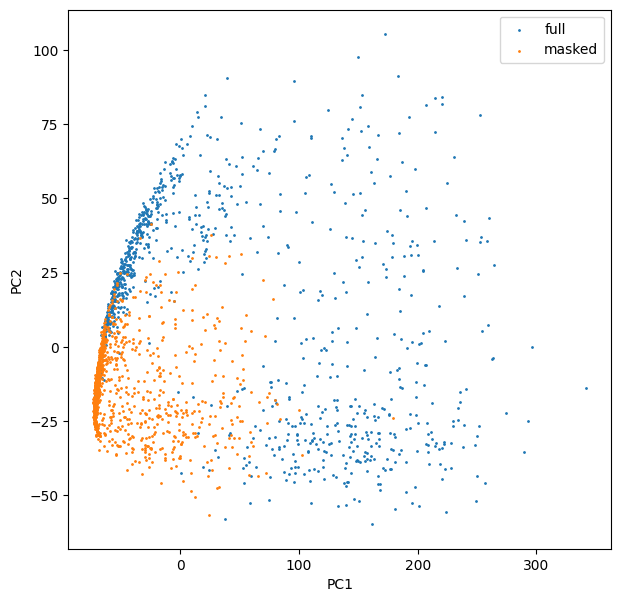

In [65]:
plt.figure(figsize=(7,7))

plt.scatter(
    latent_2d[labels==0,0],
    latent_2d[labels==0,1],
    label="full",s=1
)

plt.scatter(
    latent_2d[labels==1,0],
    latent_2d[labels==1,1],
    label="masked",s=1
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()

plt.show()